In [2]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt


# important imports 
import sys
sys.path.insert(0, "../")  
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_PROCESSES_REGRESSION import GP_REGRESSION as GP 
from TOOL_BOX_OF_FUNCTIONS.METROPOLIS_1_CHAIN import METROPOLIS_1_CHAIN as MH
from TOOL_BOX_OF_FUNCTIONS.BAYESIAN_REGRESSION import BAYES_REG as BR 
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_CRED_INTERVALS import GAUS_CRED_INTER as GCI 
from TOOL_BOX_OF_FUNCTIONS.FORMATED_PRINTING import FORMATED_PRINTING as FP 
from TOOL_BOX_OF_FUNCTIONS.METROPOLIS_1_CHAIN import METROPOLIS_1_CHAIN as MH
from TOOL_BOX_OF_FUNCTIONS.Lecture8 import exercise8 as e8
from TOOL_BOX_OF_FUNCTIONS.LECTURE_9 import exercise9 as e9

import numpy as np
import jax.numpy as jnp


# Part 1 

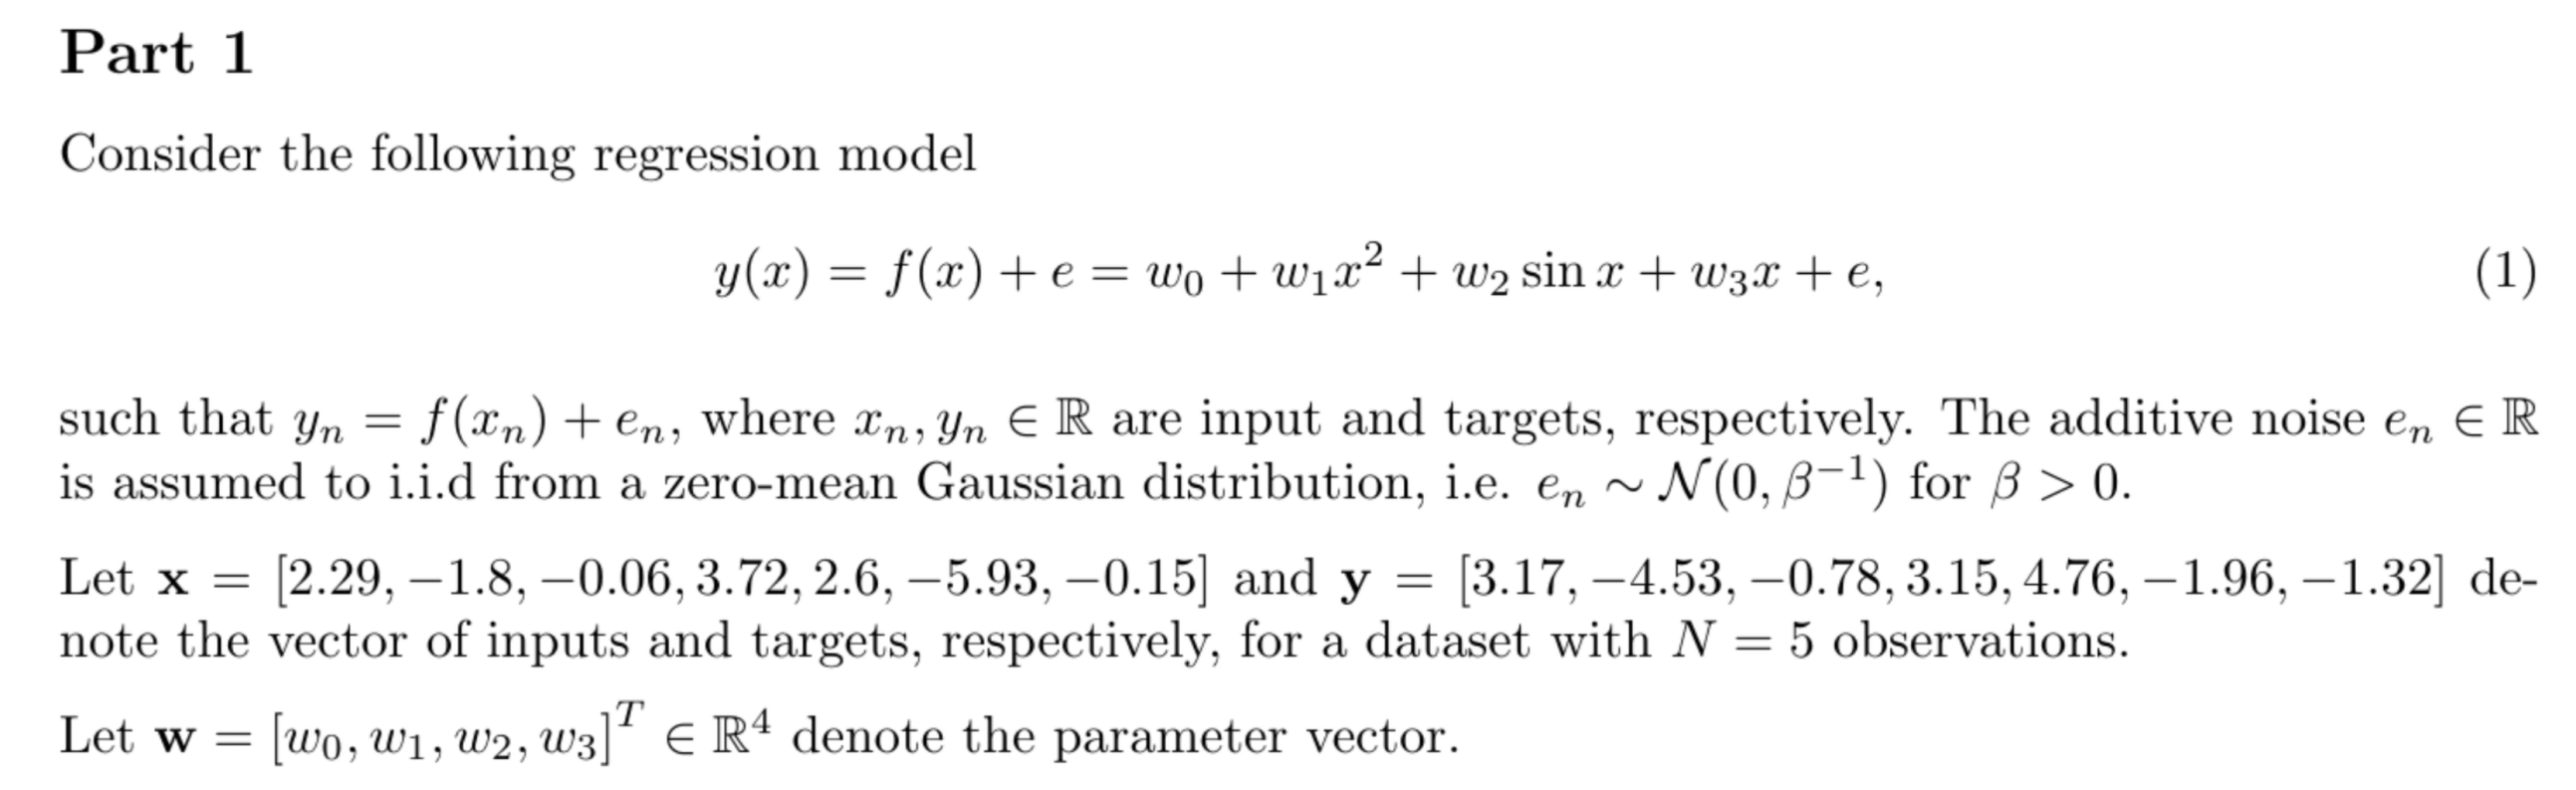

In [3]:
x = jnp.array([
    2.29, -1.8, -0.06, 3.72, 2.6, -5.93, -0.15
])

In [4]:
y = jnp.array([
    3.17, -4.53, -0.78, 3.15, 4.76, -1.96, -1.32
]).reshape(-1, 1)

In [5]:
def design_matrix(x):
    """
    Construct a design matrix Φ with a bias (intercept) term.

    Parameters:
    - x: (n,) input array

    Returns:
    - Φ: (n, 2) design matrix with ones in first column and x values in second

    Example:
    >>> x = jnp.array([1., 2., 3.])
    >>> design_matrix(x)
```
    DeviceArray([[1., 1.],
                 [1., 2.],
                 [1., 3.]], dtype=float32)
    """
    return jnp.column_stack((jnp.ones(len(x)), x**2, jnp.sin(x), x))

In [6]:
PHI = design_matrix(x)
print(PHI)
print(PHI.shape)

[[ 1.00000000e+00  5.24410000e+00  7.52330576e-01  2.29000000e+00]
 [ 1.00000000e+00  3.24000000e+00 -9.73847631e-01 -1.80000000e+00]
 [ 1.00000000e+00  3.60000000e-03 -5.99640065e-02 -6.00000000e-02]
 [ 1.00000000e+00  1.38384000e+01 -5.46691047e-01  3.72000000e+00]
 [ 1.00000000e+00  6.76000000e+00  5.15501372e-01  2.60000000e+00]
 [ 1.00000000e+00  3.51649000e+01  3.45888253e-01 -5.93000000e+00]
 [ 1.00000000e+00  2.25000000e-02 -1.49438132e-01 -1.50000000e-01]]
(7, 4)


In [7]:
model = BR.BayesianLinearRegression(Phi=PHI, y=y, beta=1, alpha=1)


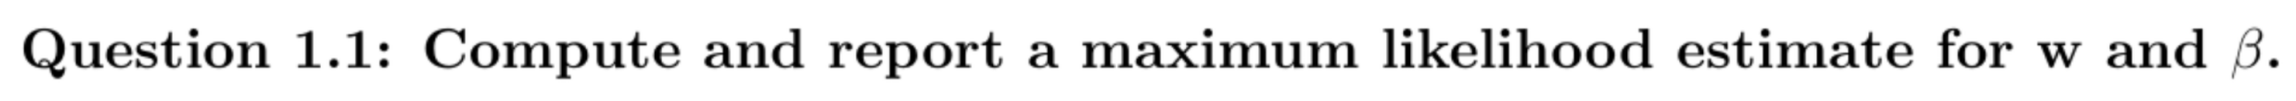

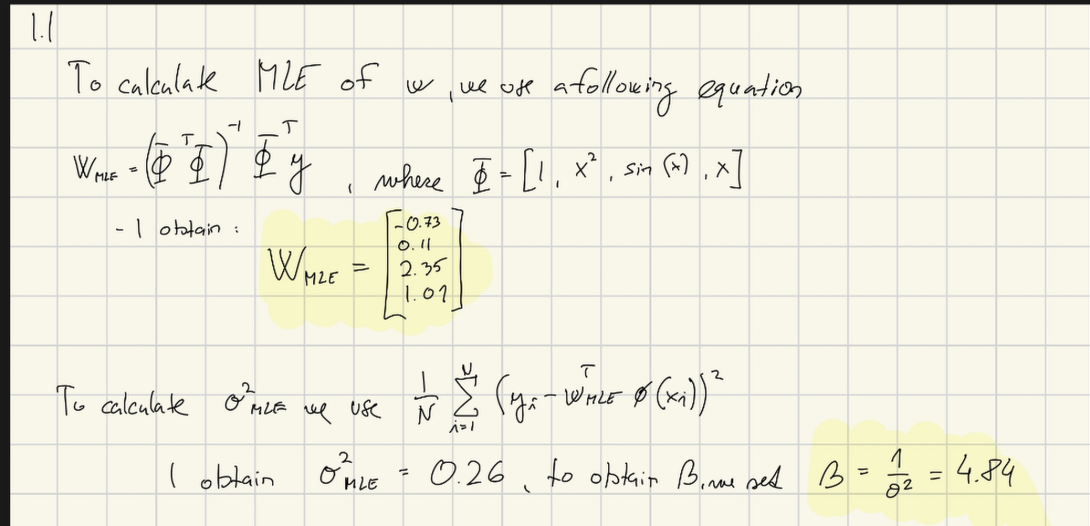

In [8]:
import numpy as np

w_MLE = model.get_w_mle()

print("w_MLE,\n", np.array2string(w_MLE, precision=2))

w_MLE,
 [[-0.73]
 [ 0.11]
 [ 2.36]
 [ 1.01]]


In [9]:
sigma = model.get_sigma2_mle()
print(f"The estimate of 1/sigma^2_MLE is {sigma}")
print(f"We obtain beta by beta_MLE = {1/sigma}")

The estimate of 1/sigma^2_MLE is 0.20655746802181824
We obtain beta by beta_MLE = 4.841267709063765


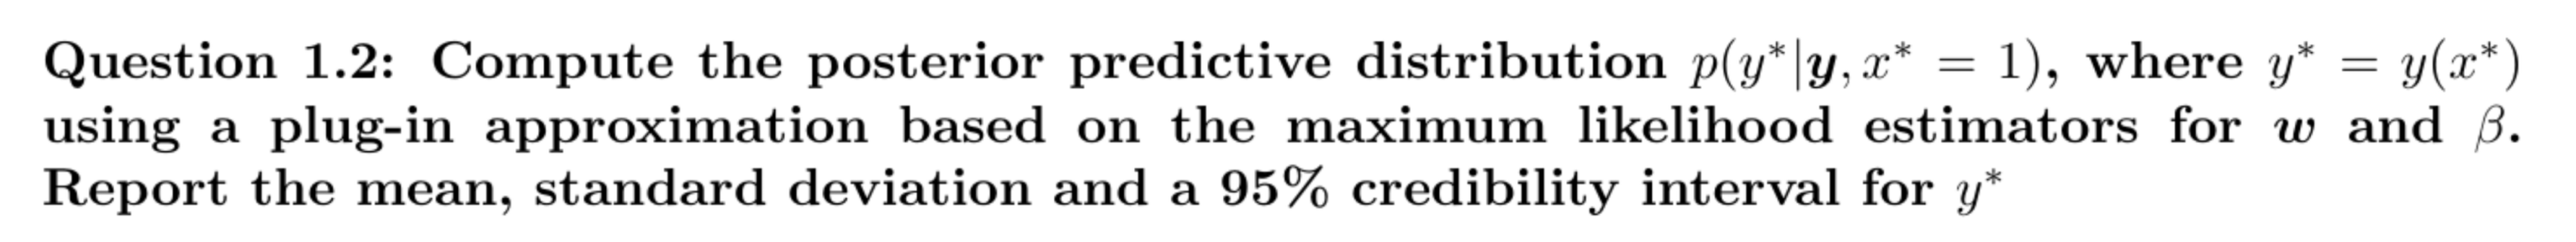


```
pythonmu_f = (Phi@self.m).ravel()   
var_f = jnp.diag(Phi@self.S@Phi.T)   

```


In [10]:
x_star = jnp.array([1])

Phi_star = design_matrix(x_star)
print(Phi_star)
print(f"Phi_star_shape {Phi_star.shape}")

[[1.         1.         0.84147098 1.        ]]
Phi_star_shape (1, 4)


In [11]:
mean_plug_in = Phi_star @ w_MLE

print(f"The mean of post. pred. dist p(y*|y, x*=1) = {mean_plug_in.item():.2f}")

The mean of post. pred. dist p(y*|y, x*=1) = 2.37


In [12]:
print(f"Variance is just {sigma:.2f}")
print(f"STD is {jnp.sqrt(sigma):.2f}")
print(f"Credibility intervals are {GCI.gaussian_credibility_interval(mean_plug_in, sigma)}")

Variance is just 0.21
STD is 0.45
Credibility intervals are (Array([[1.48313851]], dtype=float64), Array([[3.26472339]], dtype=float64))


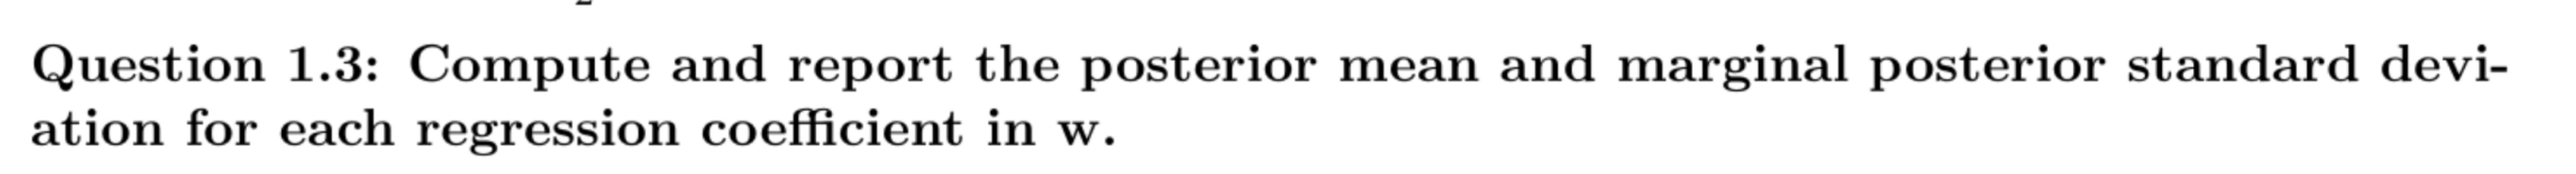

In [13]:
model2 = BR.BayesianLinearRegression(Phi=PHI, y=y, alpha=1, beta=1/2)

In [14]:
m, S = model.compute_posterior(alpha=1, beta=1/2)

In [15]:
print(f"Posterior mean is equal to \n{np.array2string(m, precision=2)}")

print(f"Posterior std of each regression coefficient w = {np.array2string(jnp.sqrt(jnp.diag(S)), precision=2)}")

Posterior mean is equal to 
[[-0.56]
 [ 0.11]
 [ 1.26]
 [ 0.99]]
Posterior std of each regression coefficient w = [0.61 0.05 0.7  0.21]


In [16]:
FP.print_fmt("Posterior mean is equal to \n", m)
FP.print_fmt("Posterior std of each regression coefficient w =",
          jnp.sqrt(jnp.diag(S)))


Posterior mean is equal to 
 [[-0.56]
 [0.11]
 [1.26]
 [0.99]]
Posterior std of each regression coefficient w = [0.61 0.05 0.70 0.21]


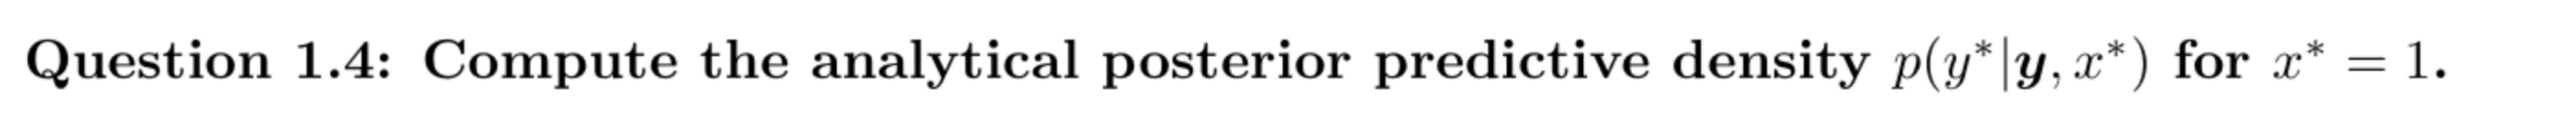

In [17]:
m_star, S_star = model2.predict_y(Phi_star)

In [18]:
FP.print_fmt(m_star)

[1.60]


In [19]:
FP.print_fmt(S_star)

[2.70]


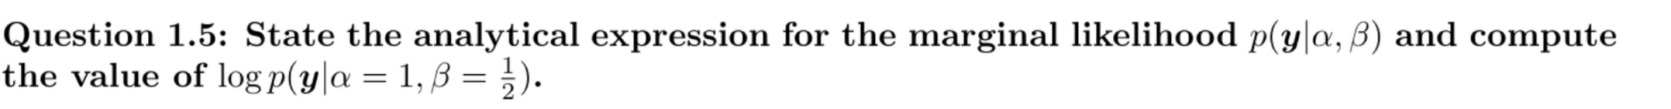

In [20]:
marg_lik = model2.log_marginal_likelihood

In [21]:
FP.print_fmt("Marginal likelihood", marg_lik)

Marginal likelihood -17.24


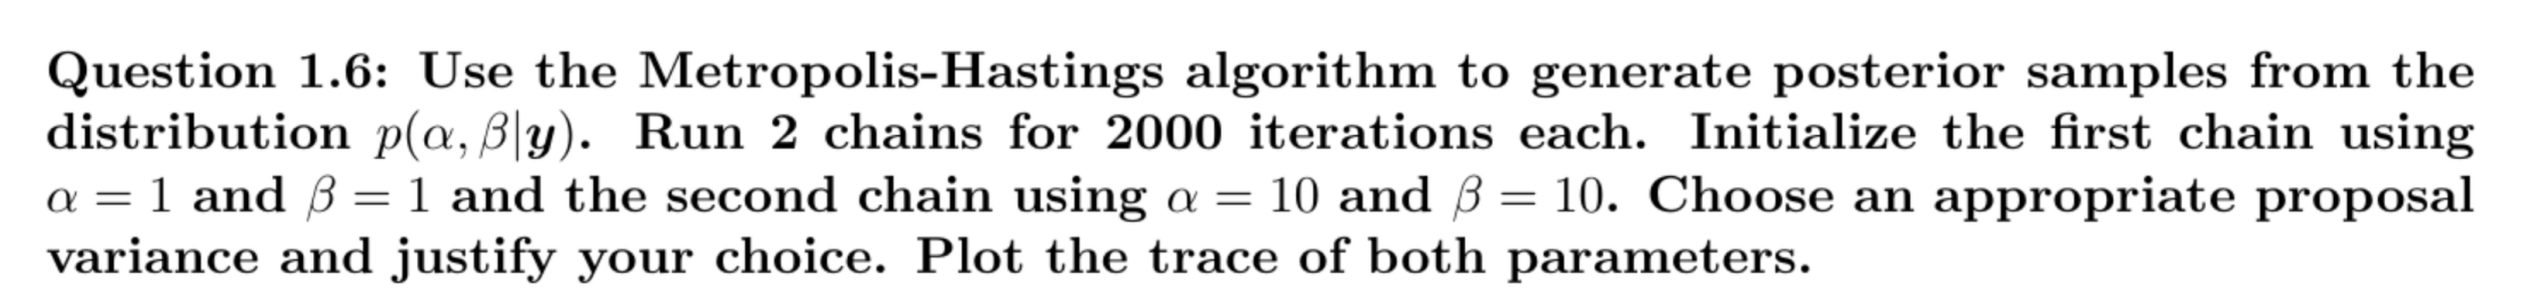

In [34]:
def poisson_log_lik(w, X, y):
    eta = X @ w 
    mu = jnp.exp(eta)
    ll = jnp.sum(y * eta - mu)
    return ll 

def log_prior_w_given_kappa(w, kappa):
    return jnp.where(kappa > 0.0, 
                     jnp.sum(log_npdf(w, 0.0, kappa*2)), 
                     -jnp.inf
                    )
    
def log_prior_kappa_half_normal(kappa):
    return log_half_npdf(kappa, 0.0, 1.0)

def log_joint_theta(theta, X, y):
    # theta = [w0, w1, kappa]
    w = theta[:2]
    kappa = theta[2]
    return poisson_log_lik(w, X, y) + log_prior_w_given_kappa(w, kappa) + log_prior_kappa_half_normal(kappa)


log_target = lambda th: log_joint_theta(th, X_train, deaths)

In [35]:
import numpy as np
from jax.scipy.stats import gamma

def log_joint_theta(theta):
    alpha, beta = theta
    model2.alpha = alpha
    model2.beta= beta 

    # support + finiteness checks
    if (alpha <= 0.0) or (beta <= 0.0) or ~jnp.isfinite(alpha + beta):
        return -jnp.inf

    # Gamma(1,1) priors (i.e., Exponential(1))
    log_prior = gamma.logpdf(alpha, a=1.0, scale=1.0) + \
                gamma.logpdf(beta,  a=1.0, scale=1.0)

    # your model’s marginal log-likelihood (must return a scalar)
    log_like = model2.compute_marginal_likelihood(alpha, beta)

    return log_prior + log_like

In [36]:
# sampler settings
num_params = 2
num_iterations = 2000
tau = 0.5
log_target = lambda th: log_joint_theta(th)

# run sampler
thetas = MH.metropolis(log_target=log_target, num_params=num_params, num_iter=num_iterations, tau=tau, theta_init=jnp.array([1, 1]), seed=0)

Acceptance ratio: 0.61
2001
(2001, 2)


In [37]:
# sampler settings
num_params = 2
num_iterations = 2000
tau = 0.5
log_target = lambda th: log_joint_theta(th)

# run sampler
thetass = MH.metropolis(log_target=log_target, num_params=num_params, num_iter=num_iterations, tau=tau, theta_init=jnp.array([10, 10]), seed=1)

Acceptance ratio: 0.58
2001
(2001, 2)


In [38]:
samples = jnp.stack((thetas, thetass))[:, 500:, :]

In [39]:
print(samples[:, :, 0].shape)

(2, 1501)


___________________________
**⚠️**

The reason you're seeing a "weird" plot in the first image (shape `(2, 1501)`) and a "nice" plot in the second image (shape `(1501, 2)`) is because of how `matplotlib.pyplot.plot` interprets array dimensions.


**🔍 What’s Happening?**

### ✅ Case 1: Shape `(1501, 2)` — **Good Plot**

This is interpreted by `plt.plot()` as:

- 1501 rows → 1501 **time steps** (x-axis)
- 2 columns → 2 **separate series** to be plotted (y-axis)

➡️ So, it plots **2 lines**, each with **1501 points**.


**❌ Case 2: Shape `(2, 1501)` — **Bad Plot**

Here, `plt.plot()` sees:

- 2 rows → **2 time steps**
- 1501 columns → Interpreted as **1501 lines**, each line using only 2 points

➡️ Result: a messy plot made of **short, disconnected segments**

---

**✅ How to Fix It**

Always ensure your data has shape **(timesteps, dimensions)** when calling `plt.plot(data)`.

So in your case, **transpose the data**:

```python
plt.plot(data.T)  # if data.shape is (2, 1501)
```
_____

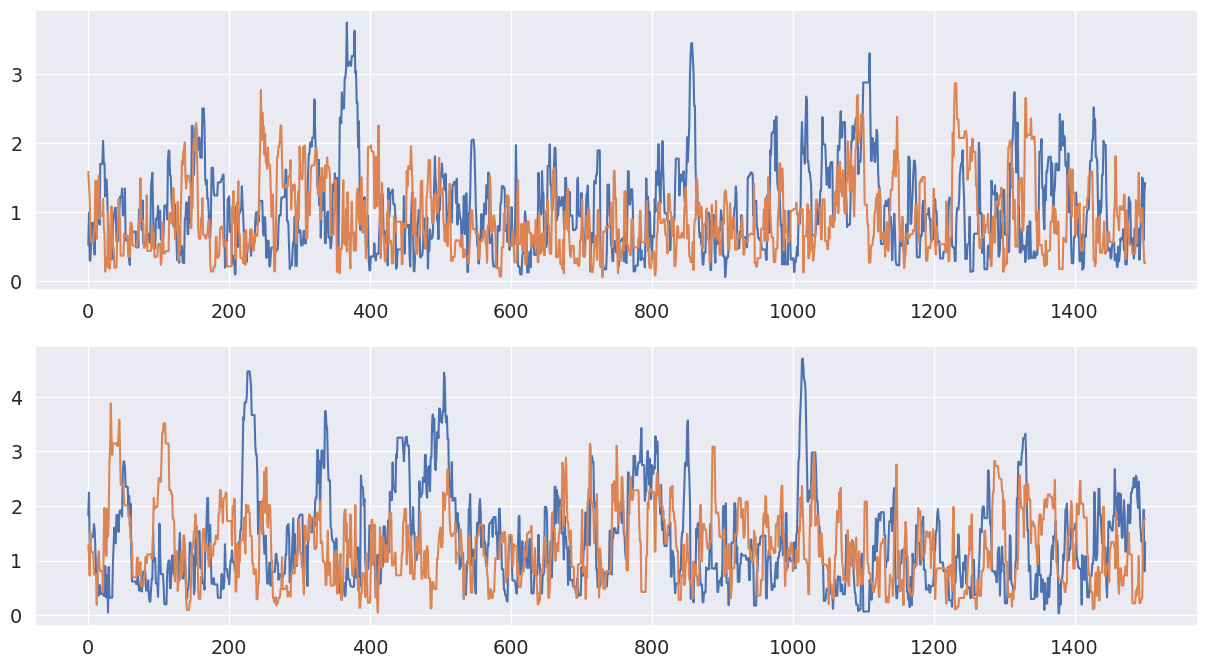

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(samples[:, :, 0].T)
axes[1].plot(samples[:, :, 1].T)

In [41]:
alpha_samples = samples[:, :, 0].T
beta_samples = samples[:, :, 1].T

FP.print_fmt(f"Posterior mean of alpha = {FP.ffmt(jnp.mean(alpha_samples))}") # The equations 
FP.print_fmt(f"Posterior mean of beta = {FP.ffmt(jnp.mean(beta_samples))}")

Posterior mean of alpha = 0.96
Posterior mean of beta = 1.30


In [42]:
S_eff = e9.compute_effective_sample_size(samples)

estimated_var = jnp.var(samples)
estimated_std = jnp.sqrt(estimated_var)
FP.print_fmt("Estiamted variance", estimated_var)

# estimate MC error
MC_error = estimated_std/jnp.sqrt(S_eff)

FP.print_fmt("MCSE errors =", MC_error)

Estiamted variance 0.52
MCSE errors = [0.06 0.05]


# Part 2 

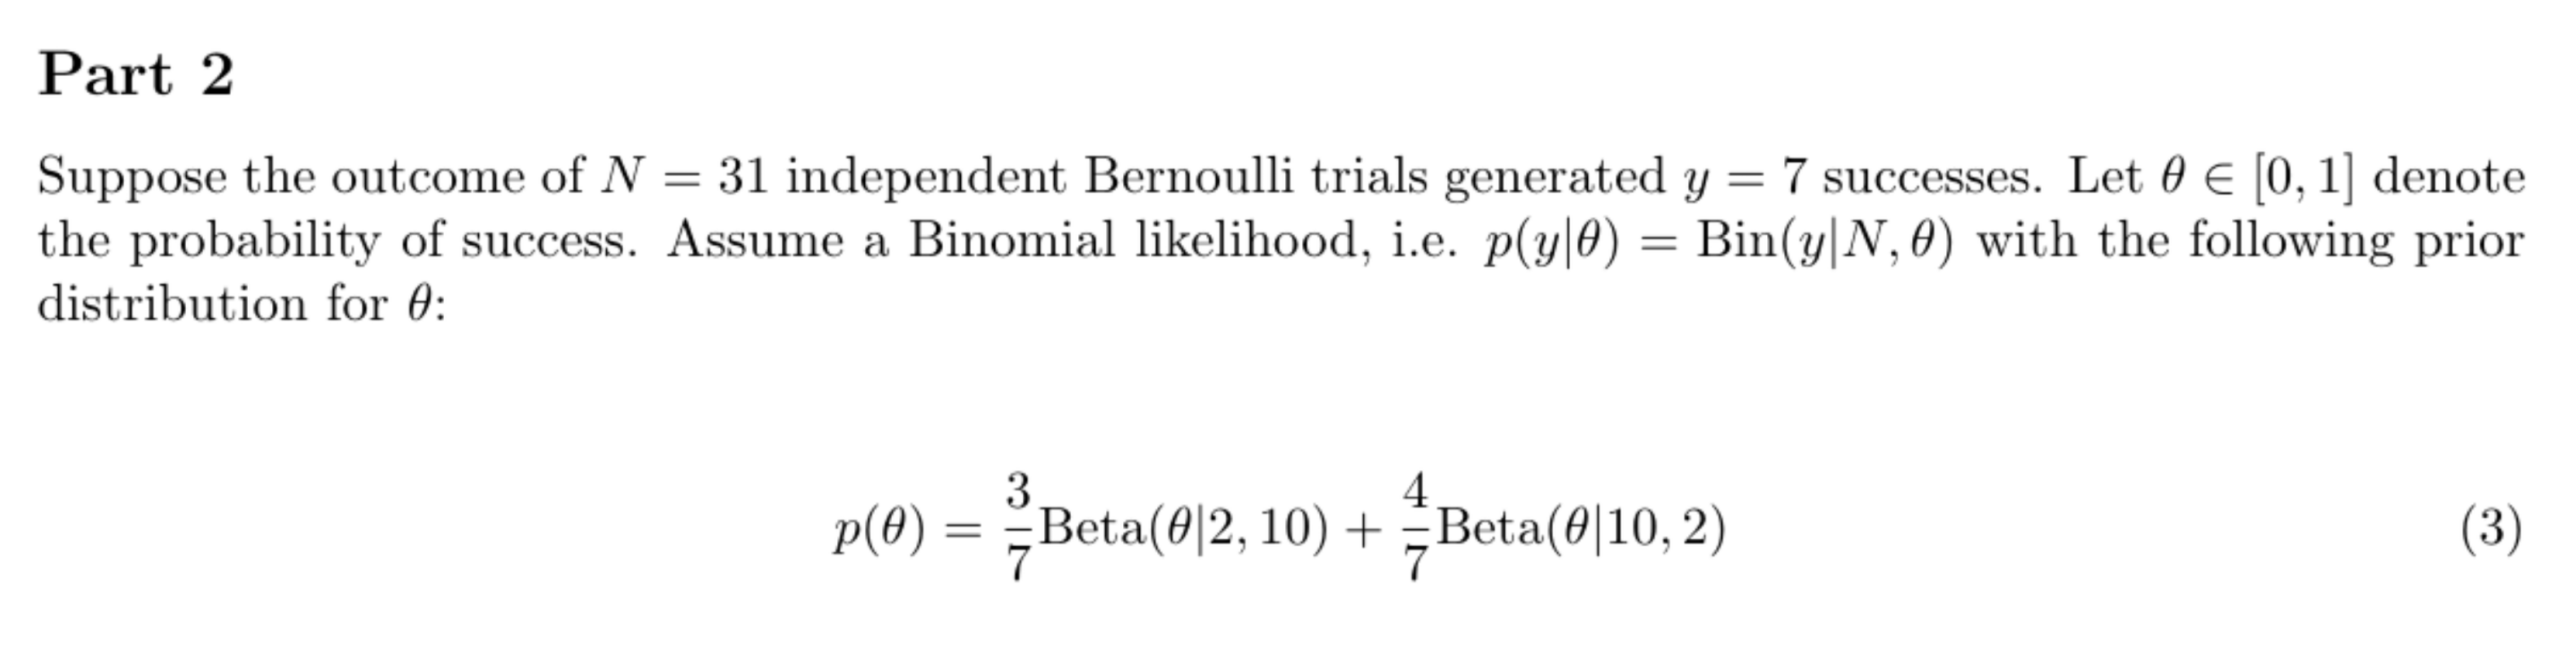

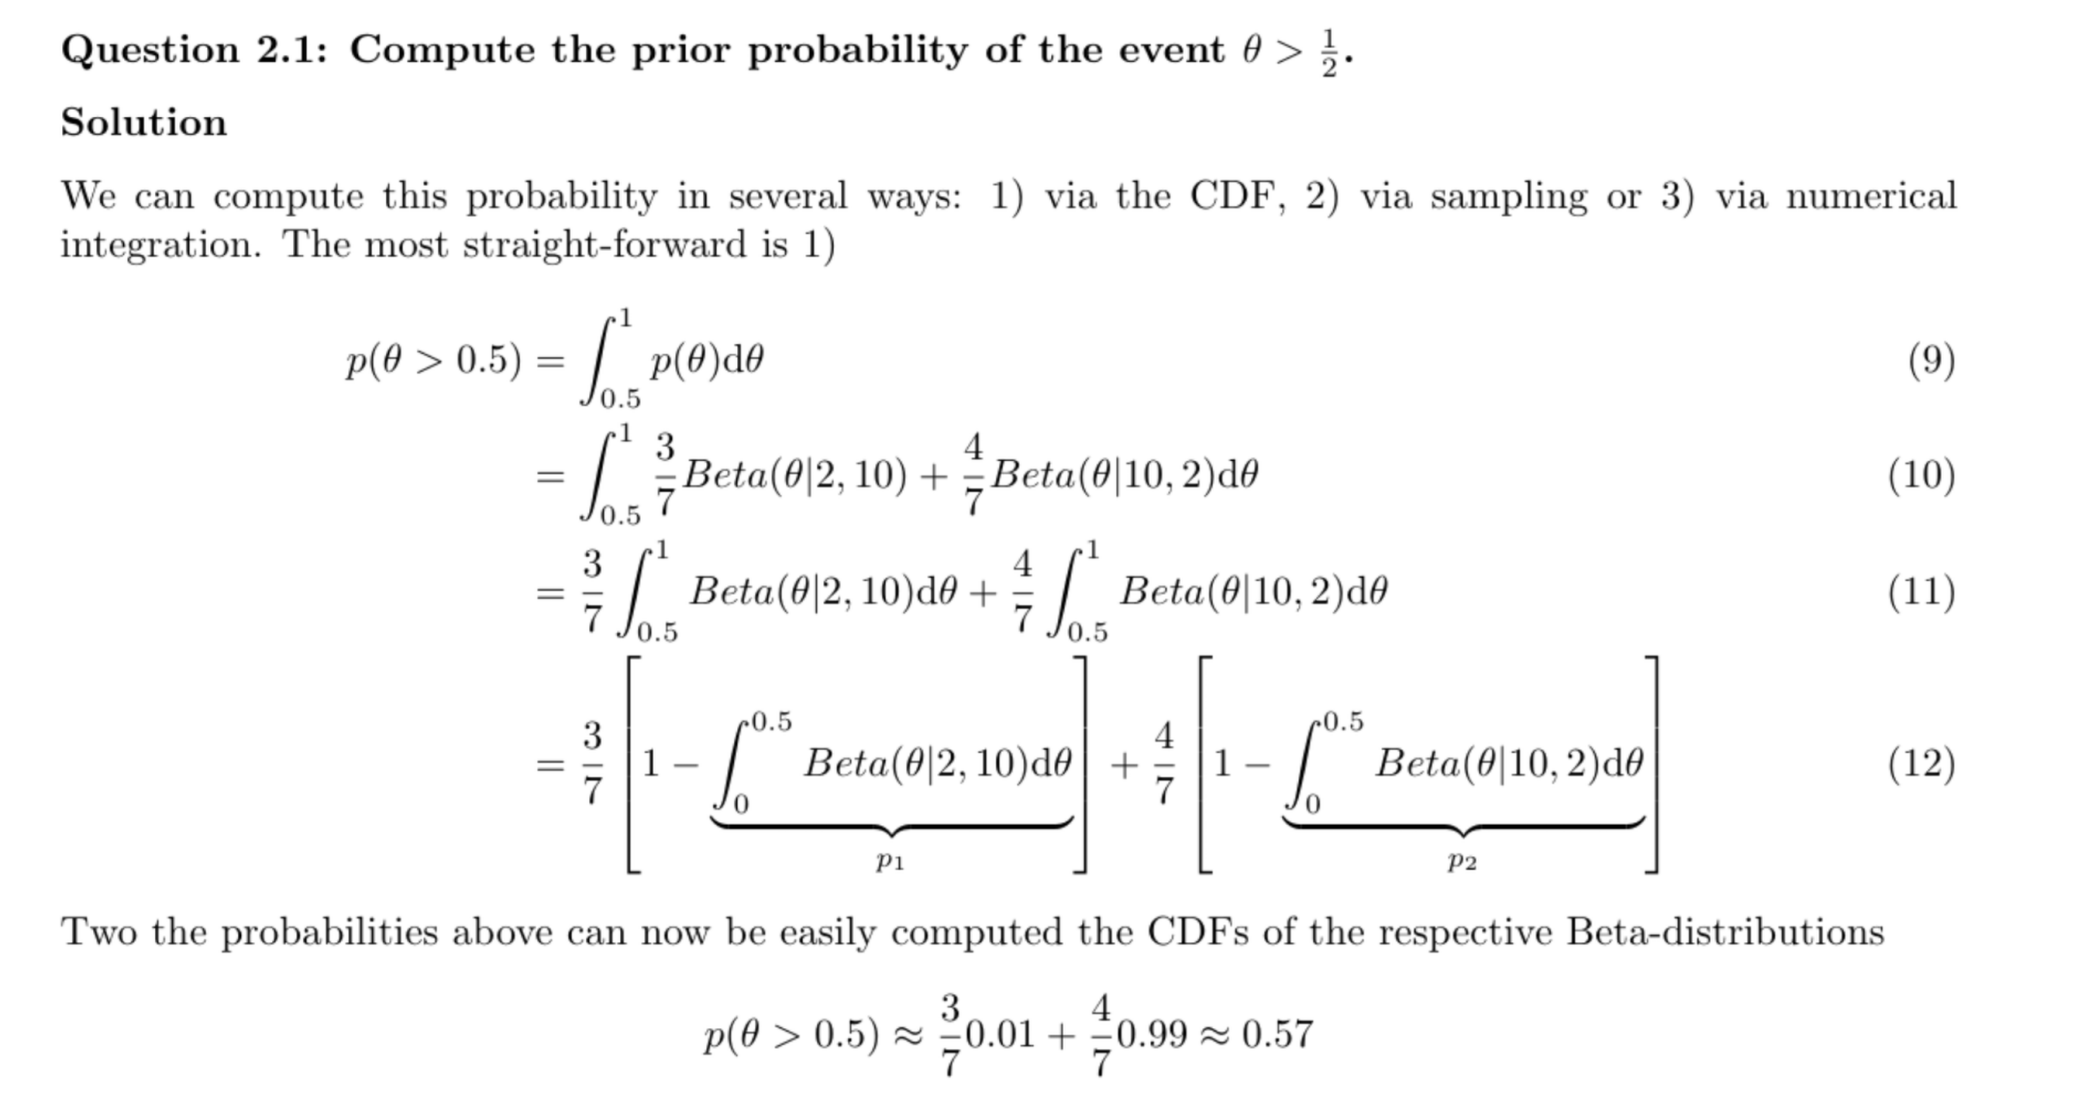


##### 🔢 Task Q2.1 — Prior-Only Calculation

We are told:
- $N = 31 $, $ y = 7 $ — **but these are not used** for this question.
- **Q2.1 is a prior question**. So we **work only with the prior**:

$$
p(\theta) = \frac{3}{7} \, \text{Beta}(2, 10) + \frac{4}{7} \, \text{Beta}(10, 2)
$$

---

**🧠 Step 1: Mixture = Hidden Switch + Law of Total Probability**

### Hidden switch idea:
Let $ Z \in \{1, 2\} $ be a hidden variable with:
- $ \mathbb{P}(Z = 1) = \frac{3}{7} $
- $ \mathbb{P}(Z = 2) = \frac{4}{7} $

Conditional on \( Z \), draw:
- $ \theta \mid Z = 1 \sim \text{Beta}(2, 10) $
- $ \theta \mid Z = 2 \sim \text{Beta}(10, 2) $

---

**Law of Total Probability:**

For **any** event $ A $:

$$
\mathbb{P}(A) = \sum_z \mathbb{P}(Z = z) \cdot \mathbb{P}(A \mid Z = z)
$$

We choose the event:

$$
A = \{ \theta > \tfrac{1}{2} \}
$$

Then:

$$
\mathbb{P}(\theta > \tfrac{1}{2}) = \frac{3}{7} \, \mathbb{P}_{\text{Beta}(2, 10)}(\theta > \tfrac{1}{2}) + \frac{4}{7} \, \mathbb{P}_{\text{Beta}(10, 2)}(\theta > \tfrac{1}{2})
$$

---

✅ That’s the **full setup** for computing the prior probability that $ \theta > \tfrac{1}{2} $ under the mixture prior.


**Mixture via a Bernoulli indicator**

Let $z \sim \mathrm{Bernoulli}(\pi)$ select the component: $z=1$ means “use component 1,” and $z=0$ means “use component 2.”  
Set $\pi=\tfrac{3}{7}.$

Define independent draws
$$
\theta_1 \sim \mathrm{Beta}(2,10), \qquad \theta_2 \sim \mathrm{Beta}(10,2).
$$

Construct the mixture sample as
$$
\theta \;=\; z\,\theta_1 + (1-z)\,\theta_2.
$$

**Sanity check**

- If $z=1$, then $\theta=\theta_1$.  
- If $z=0$, then $\theta=\theta_2$.  
(If you swapped the terms, $z=1$ would incorrectly select $\theta_2$.)

**Quantity of interest**

Estimate $\mathbb{P}(\theta>0.5)$ by Monte Carlo:
$$
\widehat{p} \;=\; \frac{1}{N}\sum_{i=1}^{N} \mathbf{1}\!\left(\theta^{(i)} > 0.5\right).

\widehat{p} \;=\; \frac{1}{N}\sum_{i=1}^{N} \mathbf{1}\!\left(\theta^{(i)} > 0.5\right).
$$

**Analytic shortcut**

Because it’s a 2-component mixture,
$$\mathbb{P}(\theta>0.5)
\;=\;
\pi\,\mathbb{P}(\theta_1>0.5)
\;+\;
(1-\pi)\,\mathbb{P}(\theta_2>0.5).
\mathbb{P}(\theta>0.5)
\;=\;
\pi\,\mathbb{P}(\theta_1>0.5)
\;+\;
(1-\pi)\,\mathbb{P}(\theta_2>0.5).
$$


In [ ]:
from scipy.stats import beta as beta_dist 

np.random.seed(0)

N = int(1e6)
z = np.random.binomial(1, p=3/7, size=N)
theta_1 = beta_dist.rvs(2, 10, size=N)
theta_2 = beta_dist.rvs(10, 2, size=N)


theta = (z * theta_1) + ((1 - z) * theta_2 )

prob = np.mean(theta > 0.5)
print(f"p(theta > 0.5) = {FP.ffmt(prob)}")

p(theta > 0.5) = 0.57


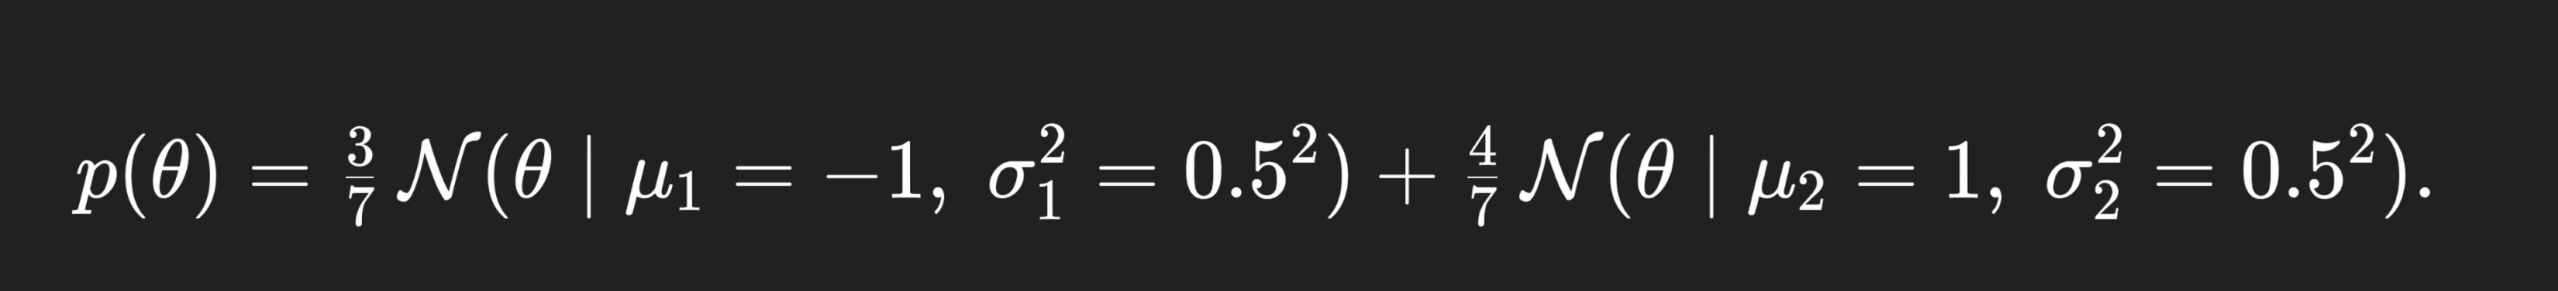

Following can also be done for Gaussian Mixture 

In [ ]:
import jax
import jax.numpy as jnp
from jax import random
from jax.scipy.stats import norm

mu_1, sigma_1 = -1.0, 0.5
mu_2, sigma_2 = 1, 0.5

# Initialize random key
key = random.PRNGKey(42)

# Split key for two separate draws
key1, key2 = random.split(key)

z = np.random.binomial(1, p=4/7, size=N)
# Draw samples
theta_1 = random.normal(key1, shape=(N,)) * sigma_1 + mu_1
theta_2 = random.normal(key2, shape=(N,)) * sigma_2 + mu_2

theta = theta_1 * (1 - z) + theta_2 * (z)

prob = np.mean(theta > 0.5)
print(f"p(theta > 0.5) = {FP.ffmt(prob)}")

p(theta > 0.5) = 0.48


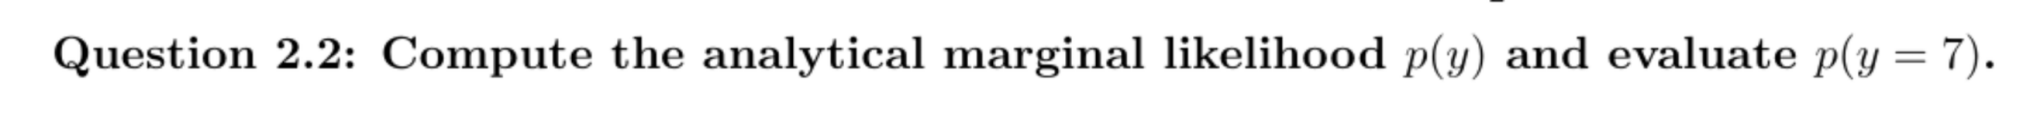

```python 
from scipy.special import beta as B, comb 
N, y = 31, 7 
term1 = (3/7) * comb(N, y) * B(y+2, N-y+10) / B(2, 10) 
term2 = (4/7) * comb(N, y) * B(y+10, N-y+2) / B(10, 2) 
p_y = term1 + term2 
print(p_y) # ~ 0.03 ```

Beta density:
$$
f(\theta\mid \alpha,\beta)=\frac{\theta^{\alpha-1}(1-\theta)^{\beta-1}}{B(\alpha,\beta)}, \qquad 0<\theta<1,
$$
where
$$
B(\alpha,\beta)=\frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}.
$$

# PART 3 

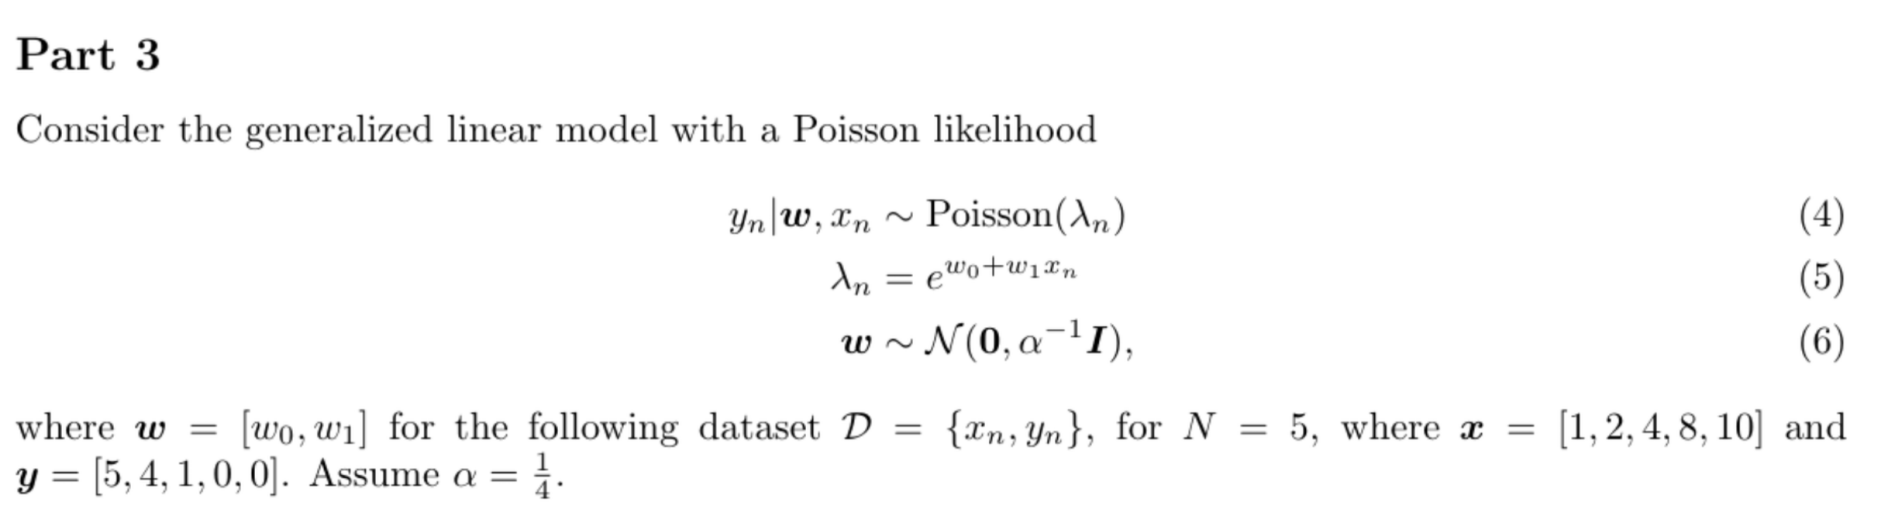

In [45]:
class Grid2D(object):
    """
    Helper class for evaluating a function func on a 2D grid defined by (alpha, beta) parameters.
    
    Purpose: Enables visualization and analysis of probability distributions over parameter space
    for Bayesian inference in logistic regression.
    
    Mathematical Context:
    - For logistic regression: P(y|x) = sigmoid(alpha + beta*x)
    - We want to analyze: P(alpha, beta | data) ∝ P(data | alpha, beta) * P(alpha, beta)
    """

    def __init__(self, alphas, betas, func, name="Grid2D"):
        """
        Initialize the 2D grid and evaluate the function at all grid points.
        
        Args:
            alphas: 1D array of alpha values, shape (n_alpha,)
            betas: 1D array of beta values, shape (n_beta,) 
            func: Function to evaluate, takes (alpha, beta) and returns scalar or array
            name: String identifier for plotting
        """
        self.alphas = alphas                    # Shape: (n_alpha,)
        self.betas = betas                      # Shape: (n_beta,)
        self.grid_size = (len(self.alphas), len(self.betas))  # (n_alpha, n_beta) 
        # self.grid_size stores (J, K) so later we can map a 1-D index back to 2-D coordinates (needed for argmax)
        
        # Create 2D coordinate matrices for vectorized function evaluation
        # indexing='ij' means alpha varies along rows, beta along columns
        self.alpha_grid, self.beta_grid = jnp.meshgrid(alphas, betas, indexing='ij')
        # Shapes: alpha_grid (n_alpha, n_beta), beta_grid (n_alpha, n_beta)
        # Note: This produces two (J, K) arrays, A_jk = alphas[j] and B_jk = betas[k]
        
        self.func = func # Function to evaluate on the grid e.g. log_prior, log_likelihood, log_joint
        self.name = name # Identifier for the grid, used in plots, e.g. 'Prior', 'Likelihood', 'Posterior'
        
        # Evaluate function on each grid point
        # Add None dimension for broadcasting, then squeeze to remove singleton dims
        # Input shapes: (n_alpha, n_beta, 1) each
        # Output shape after squeeze: (n_alpha, n_beta)
        self.values = self.func(self.alpha_grid[:, :, None], self.beta_grid[:, :, None]).squeeze()
        # Note: Broadcasting trick: [:, :, None] adds a singleton 3ʳᵈ dimension so the model 
        # functions—written to accept shapes (batch, 1) or (1, batch)—work unchanged.
        # .squeeze() removes that dummy dimension → a plain (J,K)(J,K) table.

    def plot_contours(self, ax, color='b', num_contours=10, f=lambda x: x, alpha=1.0, title=None):
        """
        Plot contour lines of the evaluated function.
        
        Args:
            ax: Matplotlib axes object
            color: Color for contour lines
            num_contours: Number of contour levels
            f: Transform function (e.g., exp to convert log-space to probability space)
            alpha: Transparency level
            title: Optional plot title override
            
        Note: .T transpose is needed because matplotlib expects (y, x) indexing
        while our grid uses (alpha, beta) = (x, y) indexing
        """
        ax.contour(self.alphas, self.betas, f(self.values).T, num_contours, colors=color, alpha=alpha)
        ax.set(xlabel='$\\alpha$', ylabel='$\\beta$')
        ax.set_title(self.name, fontweight='bold')

    @property
    def argmax(self):
        """
        Find the (alpha, beta) coordinates of the maximum value.
        
        Returns:
            tuple: (alpha_max, beta_max) coordinates
            
        Mathematical meaning:
        - For log-likelihood: gives MLE (Maximum Likelihood Estimate)
        - For log-posterior: gives MAP (Maximum A Posteriori) estimate
        """
        idx = jnp.argmax(self.values)  # Flattened index of maximum
        # Convert flat index back to 2D coordinates
        alpha_idx, beta_idx = jnp.unravel_index(idx, self.grid_size)
        return self.alphas[alpha_idx], self.betas[beta_idx]


In [46]:
x = jnp.array([1, 2, 4, 8, 10])

y = jnp.array([5, 4, 1, 0, 0])

In [47]:
def prior(w0, w1):
    p = (log_npdf(w0, 0.0, 1/4) + log_npdf(w1, 0.0, 1/4)).sum(axis=2)
    print(p.shape)
    return p


from scipy.stats import poisson

def log_lik(w0, w1):
    l = poisson.logpmf(y, jnp.exp(w0 + w1 * x)).sum(axis=2)
    print(l.shape)
    return l

def posterior(w0, w1):
    p = prior(w0, w1)
    l = log_lik(w0, w1)
    return p + l

In [52]:
w0 = jnp.linspace(-3.5, 3.5, 100)
w1 = jnp.linspace(-3.5, 3.5, 100)


log_npdf = lambda x, m, v: -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)


In [53]:
# Prior: Encodes belief before seeing data
log_prior_grid = Grid2D(alphas=w0, betas=w1, func=prior, name="Prior")
log_grid_loglik = Grid2D(alphas=w0, betas=w1, func=log_lik, name="Log-likelihood")
posterior = Grid2D(alphas=w0, betas=w1, func=posterior, name="Posterior")

(100, 100)
(100, 100)
(100, 100)
(100, 100)


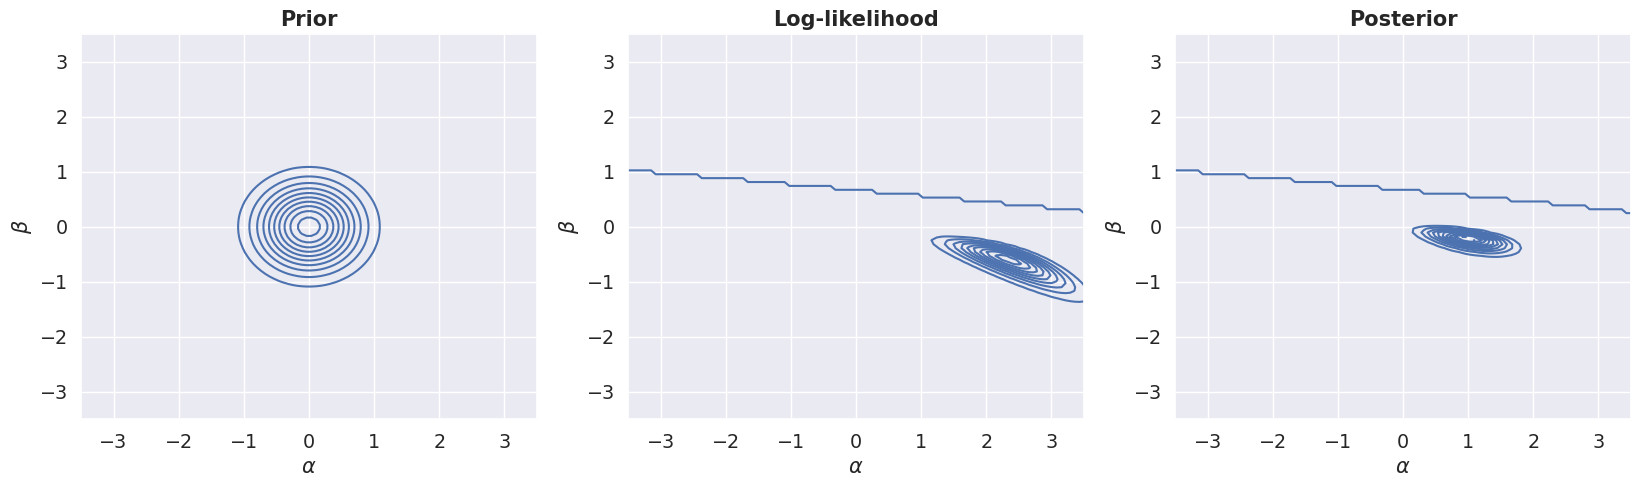

In [54]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
log_prior_grid.plot_contours(ax[0], f=np.exp)
log_grid_loglik.plot_contours(ax[1], f=np.exp)
posterior.plot_contours(ax[2], f=np.exp)

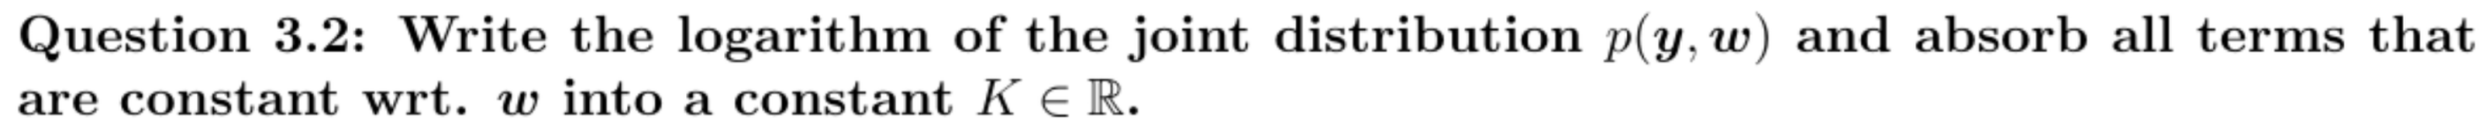

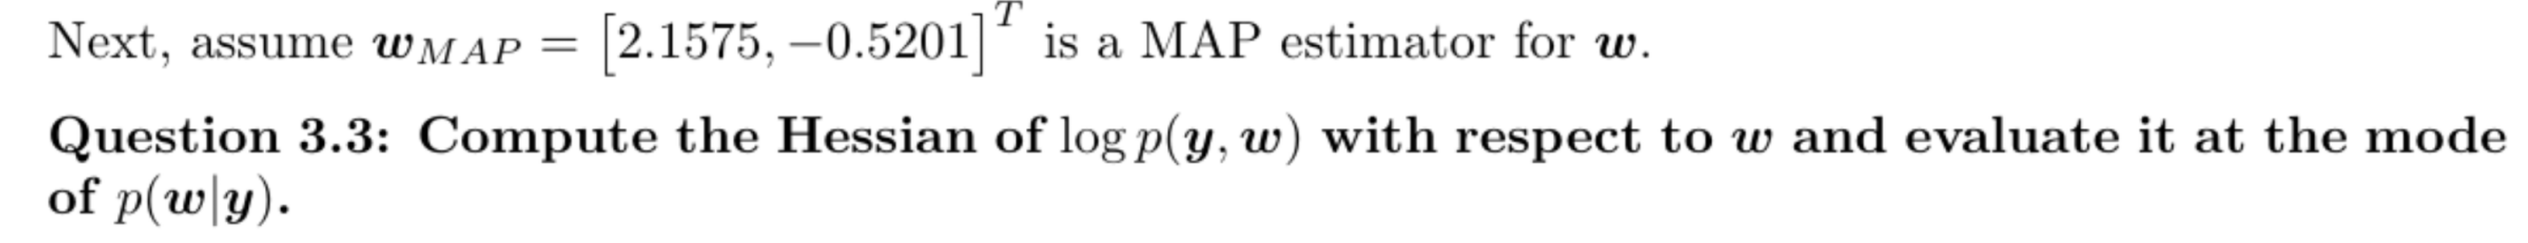

In [132]:
import jax.numpy as jnp
from jax import grad, hessian, jit

def L(w, X, y, alpha):
    """
    w: (d,)
    X: (N, d)
    y: (N,)
    alpha: scalar >= 0 (Gaussian prior precision)
    """
    # ensure 1-D parameter vector
    w   = w.ravel()             # (d,)
    eta = X @ w                 # (N,)
    lam = jnp.exp(eta)          # (N,)

    # prior:  - (alpha/2) * w^T w
    prior = -0.5 * alpha * jnp.dot(w, w)   # scalar

    # Poisson log-likelihood: sum_n (y_n * eta_n - lam_n)
    ll = jnp.dot(y, eta) - jnp.sum(lam)    # scalar

    return prior + ll                       # scalar

grad_L = jit(grad(L))
hess_L = jit(hessian(L))


# 1) build design matrix with intercept
X = jnp.c_[jnp.ones_like(x), x] # shape (N,2)

# 2) parameter vector
w = jnp.array([2.1575, -0.5201])   # shape (2,)

# 3) Hessian
H = hess_L(w, X, y, 1/4)  # shape (2,2)


In [133]:
H

Array([[ -9.711081  , -17.13135724],
       [-17.13135724, -48.30024432]], dtype=float64)

In [134]:
S = - jnp.linalg.inv(H)  # shape (2,2)
print(S)

[[ 0.27511445 -0.09757888]
 [-0.09757888  0.05531357]]


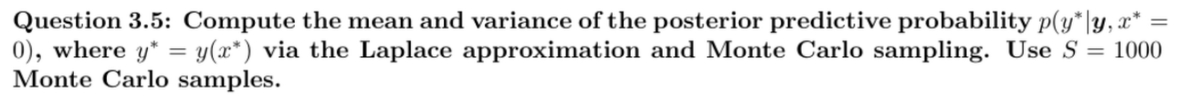

In [135]:
x_star = 0.0 

from jax import random

mu = jnp.array([2.1575, -0.5201])  # shape (2,)
Sigma = jnp.array([[0.33566434, -0.11888112],
                   [-0.11888112,  0.06293706]])  # shape (2,2)

X_star = jnp.array([1, x_star])  # shape (2,)
S_ = 50000                         # number of MC samples (scalar)

key = random.PRNGKey(0)
key_w, key_y = random.split(key)

w_s = random.multivariate_normal(key_w, mean=mu, cov=S, shape=(S_,))  # shape (S, 2)

# linear predictor and rates 
eta_s = w_s @ X_star  # shape (S,)
lam_s = jnp.exp(eta_s)  # shape (S,)

# ----- Full predictive sampling -----
y_s = random.poisson(key_y, lam=lam_s)   # (S,)

pred_mean_mc = jnp.mean(y_s)
pred_var_mc  = jnp.var(y_s)

print("Predictive mean (MC):", pred_mean_mc)
print("Predictive variance (MC):", pred_var_mc)

Predictive mean (MC): 9.985880000000002
Predictive variance (MC): 41.4547206256


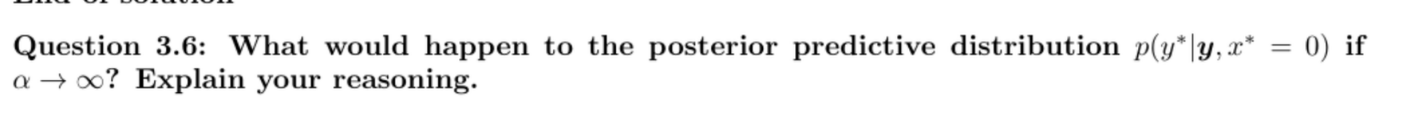

## What happens as $\alpha \to \infty$?

We assume the prior:

$$
w \sim \mathcal{N}(0, \alpha^{-1} I),
$$

so $\alpha$ is the **prior precision** (i.e., the inverse variance). The likelihood is based on a **Poisson model** with a **log link**, so the rate is:

$$
\lambda(x) = \exp(w^\top x).
$$

---

### 1. Behavior of the Prior

Each coordinate of $w$ satisfies:

$$
w_j \sim \mathcal{N}(0, 1/\alpha),
$$

so:

$$
\text{Var}(w_j) = \alpha^{-1} \to 0 \quad \Rightarrow \quad w \to 0.
$$

Equivalently, the prior density is:

$$
p(w \mid \alpha) = \left( \frac{\alpha}{2\pi} \right)^{d/2} \exp\left( -\frac{\alpha}{2} \|w\|^2 \right),
$$

which concentrates all mass at $w = 0$ as $\alpha \to \infty$. In the limit, the prior becomes a **point mass**:

$$
p(w) \to \delta(w = 0).
$$

---

### 2. Effect on the Posterior

The unnormalized log-posterior is:

$$
\log p(w \mid y) = \underbrace{\ell(w; y)}_{\text{log-likelihood}} - \frac{\alpha}{2} \|w\|^2.
$$

- **Mode condition**:

  $$
  \nabla \ell(w) - \alpha w = 0 \quad \Rightarrow \quad w_{\text{MAP}} = \frac{1}{\alpha} \nabla \ell(w).
  $$

  As $\alpha \to \infty$, the prior dominates and:

  $$
  w_{\text{MAP}} \to 0.
  $$

- **Posterior curvature**:

  $$
  -\nabla^2 \log p(w \mid y) = -\nabla^2 \ell(w) + \alpha I,
  $$

  so the posterior covariance shrinks:

  $$
  \text{Cov}(w \mid y) \approx (\alpha I + \text{data term})^{-1} \to 0.
  $$

Therefore, the posterior also **collapses to a point mass at zero**:

$$
p(w \mid y) \to \delta(w = 0).
$$

---

### 3. Consequence for the Predictive at $x^* = 0$

With a log link, the rate is:

$$
\lambda^*(w) = \exp(w^\top x^*) \Rightarrow \lambda^*(w) = \exp(w_0) \quad \text{if } x^* = 0.
$$

As $w_0 \to 0$, this becomes:

$$
\lambda^* \to \exp(0) = 1 \quad \Rightarrow \quad p(y^* \mid x^*, y) \to \text{Poisson}(1).
$$

---

### 4. Same Conclusion via Laplace Approximation

Using Laplace:

- $w \mid y \approx \mathcal{N}(\mu, \Sigma)$
- As $\alpha \to \infty$:
  - $\mu \to 0$
  - $\Sigma \to 0$

Then at $x^* = 0$, if we define:

- $m = \mu_0$, $s^2 = \Sigma_{00}$,

we get:

$$
\mathbb{E}[y^*] = \mathbb{E}[\lambda^*] = \exp\left(m + \frac{1}{2} s^2\right) \to \exp(0) = 1,
$$

$$
\text{Var}(y^*) = \mathbb{E}[\lambda^*] + \text{Var}(\lambda^*) \to 1 + 0 = 1.
$$

Thus, the predictive behaves like $\text{Poisson}(1)$.

---

### 5. Prior Predictive Also Collapses

Even without data:

$$
w_0 \sim \mathcal{N}(0, 1/\alpha) \Rightarrow \lambda^* = \exp(w_0) \sim \text{LogNormal}(0, 1/\alpha).
$$

Then:

$$
\mathbb{E}[\lambda^*] = \exp\left(\frac{1}{2\alpha}\right) \to 1,
\quad
\text{Var}(\lambda^*) = \left( e^{1/\alpha} - 1 \right) e^{1/\alpha} \to 0.
$$

So even the **prior predictive**:

$$
p(y^* \mid x^*) \to \text{Poisson}(1).
$$

---

### 🧠 Intuition

- Larger $\alpha$ = **stronger ridge penalty** $\Rightarrow$ shrinks all $w_j$ toward 0.
- With log-link: $\lambda(x) = \exp(w^\top x) \to \exp(0) = 1$.
- Both **posterior** and **prior predictive** collapse to $\text{Poisson}(1)$.
- The model becomes uninformative: the prediction **ignores the data**.

--- 
